Original shape: (1372, 5)
Removed 24 duplicate rows
Removed 34 outliers using Z-score
Shape after preprocessing: (1314, 5)
Data standardized using Z-score normalization

Class counts: [728 586]



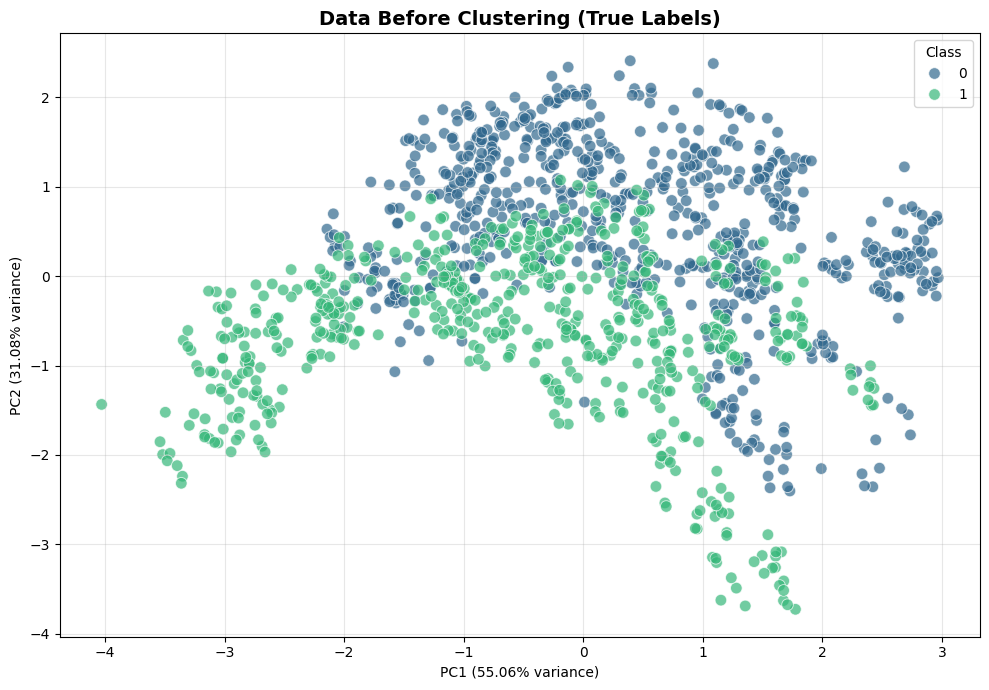

* Converged after 17 iterations
Cluster distribution: [676 638]

Aligning clusters to true labels...
  Label mapping: {np.int64(0): np.int64(1), np.int64(1): np.int64(0)}
  Best alignment accuracy: 0.550989


Evaluation Metrics for K-Means:
      Metric     Value
0     Purity  0.554033
1   Accuracy  0.550989
2  Precision  0.497041
3     Recall  0.573379
4         F1  0.532488



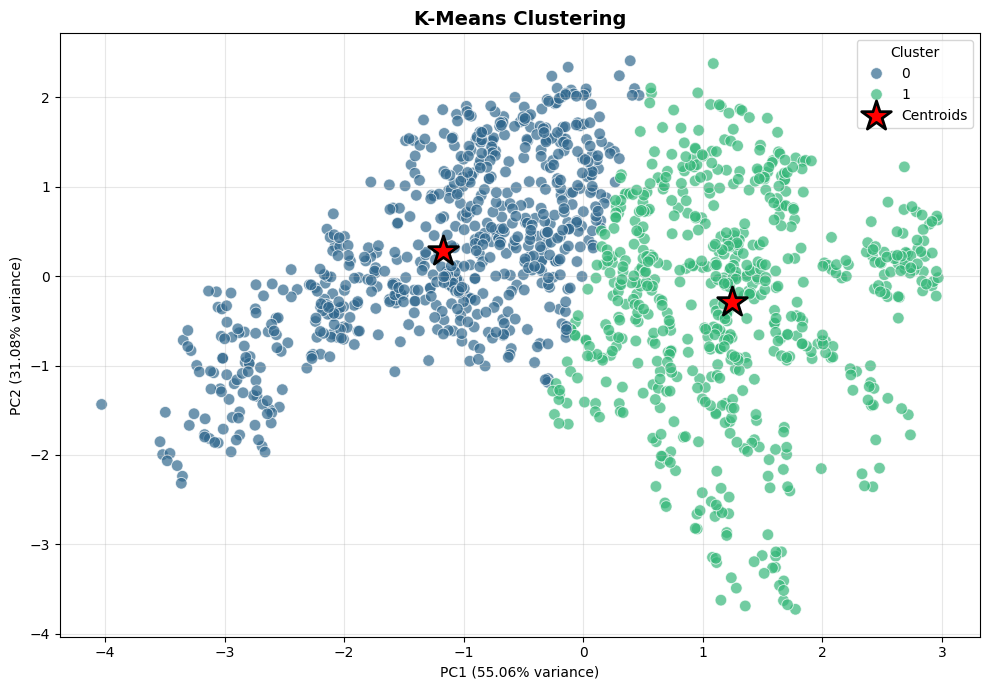

In [15]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================

filepath = "/content/banknote.csv"

def load_and_preprocess(filepath):
    """Load and preprocess data with standardization, duplicates, outliers."""
    try:
        df = pd.read_csv(filepath, header=None)
    except:
        print(f"Error loading file: {filepath}")
        return None

    print(f"Original shape: {df.shape}")

    # Remove duplicates
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - len(df)} duplicate rows")

    # Outlier removal using Z-score (only on feature columns)
    features = df.columns[:-1]
    z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())
    initial_rows = len(df)
    df = df[(z_scores < 3).all(axis=1)]
    print(f"Removed {initial_rows - len(df)} outliers using Z-score")

    # Standardization
    df[features] = (df[features] - df[features].mean()) / df[features].std()

    print(f"Shape after preprocessing: {df.shape}")
    print("Data standardized using Z-score normalization\n")
    return df


# ==========================================
# 2. K-Means from Scratch (Euclidean Distance)
# ==========================================

def k_means_clustering(data, k=2, max_iter=300, tol=1e-4, random_seed=42):
    """K-Means implementation using Euclidean distance."""
    np.random.seed(random_seed)
    N = data.shape[0]

    # Initialize centroids
    centroids_idx = np.random.choice(N, k, replace=False)
    centroids = data[centroids_idx]

    for it in range(max_iter):

        # Euclidean distances
        distances = np.zeros((N, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)

        # Assign clusters
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])

        # Check convergence
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"* Converged after {it+1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. Align Clusters to True Labels (FIXED)
# ==========================================

def align_labels(y_pred, y_true):
    """Align cluster labels to true labels by finding best matching."""
    from itertools import permutations

    best_accuracy = 0
    best_mapping = {}

    # Try all possible label permutations
    for perm in permutations(np.unique(y_pred)):
        mapping = {old: new for old, new in zip(np.unique(y_pred), perm)}
        y_aligned = np.array([mapping[label] for label in y_pred])
        acc = accuracy_score(y_true, y_aligned)

        if acc > best_accuracy:
            best_accuracy = acc
            best_mapping = mapping

    y_aligned = np.array([best_mapping[label] for label in y_pred])
    print(f"  Label mapping: {best_mapping}")
    print(f"  Best alignment accuracy: {best_accuracy:.6f}")

    return y_aligned


# ==========================================
# 4. Purity Score
# ==========================================

def purity_score(y_true, y_pred):
    """Purity calculation (cluster -> majority class)."""
    y_true = y_true.astype(int)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) > 0:
            total += np.bincount(true_labels).max()
    return total / len(y_true)


# ==========================================
# 5. Execution
# ==========================================

df = load_and_preprocess(filepath)

if df is not None:
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values.astype(int)

    # Class distribution
    print("Class counts:", np.bincount(y_true))
    print()

    # ==========================================
    # PCA Visualization BEFORE Clustering
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true,
                    palette='viridis', s=70, alpha=0.7)
    plt.title("Data Before Clustering (True Labels)", fontsize=14, fontweight='bold')
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(title="Class", loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run K-means
    labels_pred, centroids = k_means_clustering(X, k=2)

    # Check cluster distribution
    print("Cluster distribution:", np.bincount(labels_pred))
    print()

    # Align clusters for metrics
    print("Aligning clusters to true labels...")
    labels_aligned = align_labels(labels_pred, y_true)
    print()

    # ==========================================
    # Metrics (using aligned labels)
    # ==========================================

    purity = purity_score(y_true, labels_pred)
    accuracy = accuracy_score(y_true, labels_aligned)
    precision = precision_score(y_true, labels_aligned, zero_division=0)
    recall = recall_score(y_true, labels_aligned, zero_division=0)
    f1 = f1_score(y_true, labels_aligned, zero_division=0)

    results = pd.DataFrame({
        "Metric": ["Purity", "Accuracy", "Precision", "Recall", "F1"],
        "Value": [purity, accuracy, precision, recall, f1]
    })

    print("\nEvaluation Metrics for K-Means:")
    print(results)
    print()

    # ==========================================
    # PCA Visualization
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids)

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = labels_pred

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster',
                    palette='viridis', s=70, alpha=0.7)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        color='red', marker='*', s=500, edgecolors='black', linewidths=2,
        label='Centroids'
    )
    plt.title("K-Means Clustering", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster", loc='best')
    plt.grid(alpha=0.3)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.tight_layout()
    plt.show()

Original shape: (351, 35)
Removed 1 duplicate rows
Dropped constant columns: [1]
Shape after preprocessing: (350, 34)
Data standardized using Z-score normalization

Class counts: [225 125]



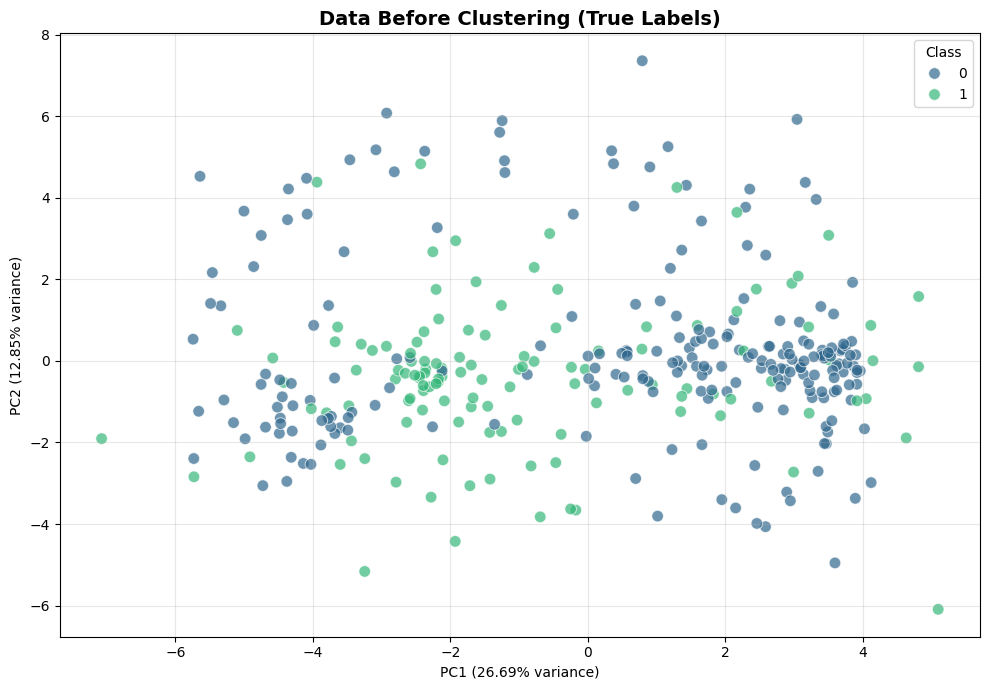

* Converged after 5 iterations
Cluster distribution: [158 192]

Aligning clusters to true labels...
  Label mapping: {np.int64(0): np.int64(1), np.int64(1): np.int64(0)}
  Best alignment accuracy: 0.705714


Evaluation Metrics for K-Means:
      Metric     Value
0     Purity  0.705714
1   Accuracy  0.705714
2  Precision  0.569620
3     Recall  0.720000
4         F1  0.636042



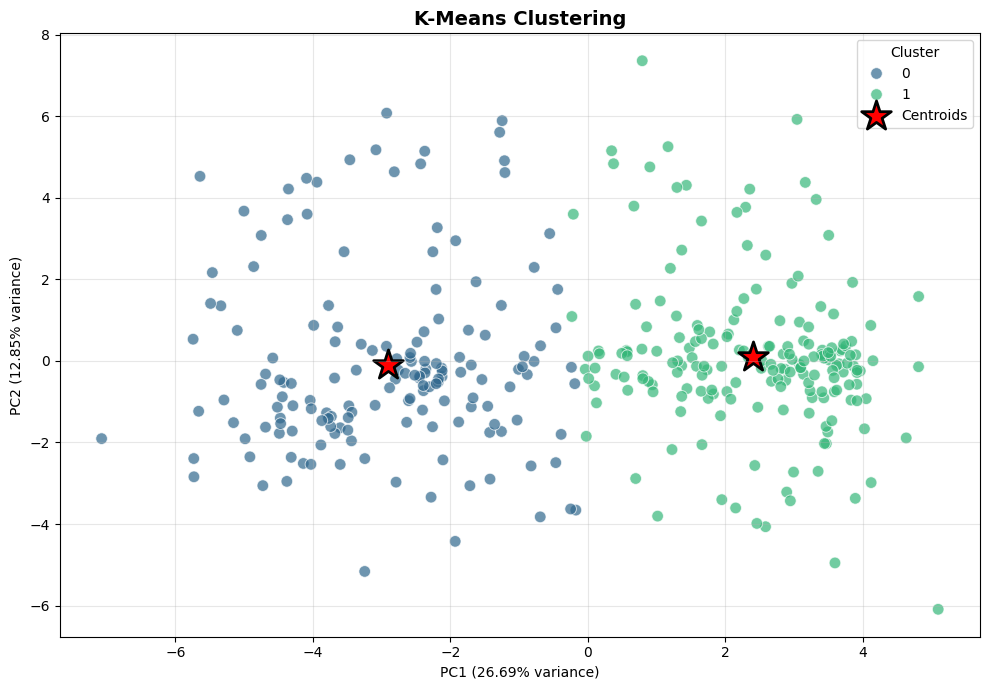

In [18]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================

filepath = "/content/ionosphere.csv"

def load_and_preprocess(filepath):
    """Load and preprocess data with standardization, duplicates, outliers."""
    try:
        df = pd.read_csv(filepath, header=None)
    except:
        print(f"Error loading file: {filepath}")
        return None

    print(f"Original shape: {df.shape}")

    # Remove duplicates
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - len(df)} duplicate rows")

    # Outlier removal using Z-score (only on feature columns)
    # Commented out as it was removing all data points for this dataset.
    # If outlier removal is desired, consider a less aggressive threshold or method.
    features = df.columns[:-1]
    # z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())
    # initial_rows = len(df)
    # df = df[(z_scores < 3).all(axis=1)]
    # print(f"Removed {initial_rows - len(df)} outliers using Z-score")

    if df.empty:
        print("Warning: DataFrame is empty after preprocessing. Cannot proceed.")
        return None

    # Identify and drop constant columns before standardization
    # Constant columns have std dev 0, which would result in NaN after standardization
    constant_columns = df[features].columns[df[features].std() == 0]
    if not constant_columns.empty:
        df.drop(columns=constant_columns, inplace=True)
        features = df.columns[:-1] # Update features after dropping columns
        print(f"Dropped constant columns: {list(constant_columns)}")

    # Standardization
    df[features] = (df[features] - df[features].mean()) / df[features].std()

    print(f"Shape after preprocessing: {df.shape}")
    print("Data standardized using Z-score normalization\n")
    return df


# ==========================================
# 2. K-Means from Scratch (Euclidean Distance)
# ==========================================

def k_means_clustering(data, k=2, max_iter=300, tol=1e-4, random_seed=42):
    """K-Means implementation using Euclidean distance."""
    np.random.seed(random_seed)
    N = data.shape[0]

    # Initialize centroids
    centroids_idx = np.random.choice(N, k, replace=False)
    centroids = data[centroids_idx]

    for it in range(max_iter):

        # Euclidean distances
        distances = np.zeros((N, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)

        # Assign clusters
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])

        # Check convergence
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"* Converged after {it+1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. Align Clusters to True Labels (FIXED)
# ==========================================

def align_labels(y_pred, y_true):
    """Align cluster labels to true labels by finding best matching."""
    from itertools import permutations

    best_accuracy = 0
    best_mapping = {}

    # Try all possible label permutations
    for perm in permutations(np.unique(y_pred)):
        mapping = {old: new for old, new in zip(np.unique(y_pred), perm)}
        y_aligned = np.array([mapping[label] for label in y_pred])
        acc = accuracy_score(y_true, y_aligned)

        if acc > best_accuracy:
            best_accuracy = acc
            best_mapping = mapping

    y_aligned = np.array([best_mapping[label] for label in y_pred])
    print(f"  Label mapping: {best_mapping}")
    print(f"  Best alignment accuracy: {best_accuracy:.6f}")

    return y_aligned


# ==========================================
# 4. Purity Score
# ==========================================

def purity_score(y_true, y_pred):
    """Purity calculation (cluster -> majority class)."""
    y_true = y_true.astype(int)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) > 0:
            total += np.bincount(true_labels).max()
    return total / len(y_true)


# ==========================================
# 5. Execution
# ==========================================

df = load_and_preprocess(filepath)

if df is not None:
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values.astype(int)

    # Class distribution
    print("Class counts:", np.bincount(y_true))
    print()

    # ==========================================
    # PCA Visualization BEFORE Clustering
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true,
                    palette='viridis', s=70, alpha=0.7)
    plt.title("Data Before Clustering (True Labels)", fontsize=14, fontweight='bold')
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(title="Class", loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run K-means
    labels_pred, centroids = k_means_clustering(X, k=2)

    # Check cluster distribution
    print("Cluster distribution:", np.bincount(labels_pred))
    print()

    # Align clusters for metrics
    print("Aligning clusters to true labels...")
    labels_aligned = align_labels(labels_pred, y_true)
    print()

    # ==========================================
    # Metrics (using aligned labels)
    # ==========================================

    purity = purity_score(y_true, labels_pred)
    accuracy = accuracy_score(y_true, labels_aligned)
    precision = precision_score(y_true, labels_aligned, zero_division=0)
    recall = recall_score(y_true, labels_aligned, zero_division=0)
    f1 = f1_score(y_true, labels_aligned, zero_division=0)

    results = pd.DataFrame({
        "Metric": ["Purity", "Accuracy", "Precision", "Recall", "F1"],
        "Value": [purity, accuracy, precision, recall, f1]
    })

    print("\nEvaluation Metrics for K-Means:")
    print(results)
    print()

    # ==========================================
    # PCA Visualization
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids)

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = labels_pred

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster',
                    palette='viridis', s=70, alpha=0.7)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        color='red', marker='*', s=500, edgecolors='black', linewidths=2,
        label='Centroids'
    )
    plt.title("K-Means Clustering", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster", loc='best')
    plt.grid(alpha=0.3)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.tight_layout()
    plt.show()

Original shape: (208, 61)
Removed 0 duplicate rows
Shape after preprocessing: (208, 61)
Data standardized using Z-score normalization

Class counts: [ 97 111]



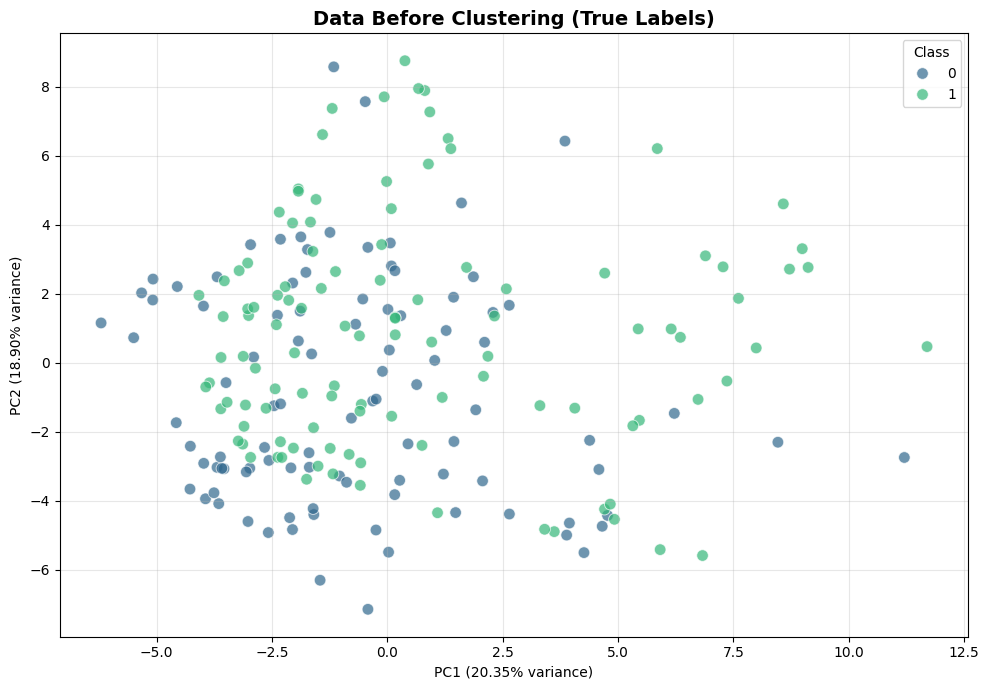

* Converged after 4 iterations
Cluster distribution: [ 43 165]

Aligning clusters to true labels...
  Label mapping: {np.int64(0): np.int64(1), np.int64(1): np.int64(0)}
  Best alignment accuracy: 0.548077


Evaluation Metrics for K-Means:
      Metric     Value
0     Purity  0.548077
1   Accuracy  0.548077
2  Precision  0.697674
3     Recall  0.270270
4         F1  0.389610



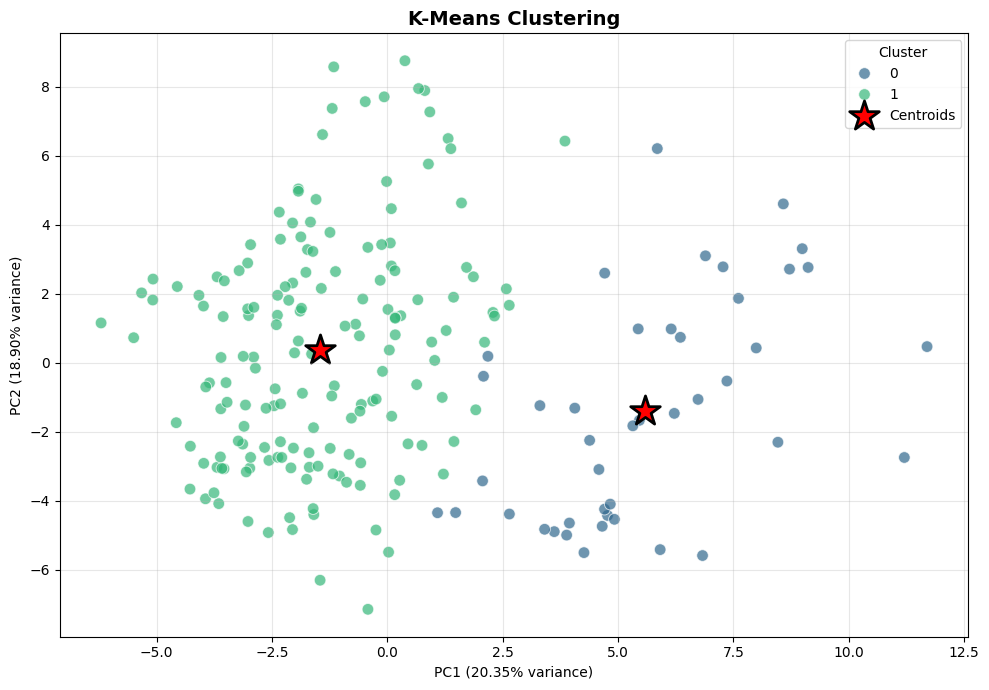

In [21]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================

filepath = "/content/sonar.csv"

def load_and_preprocess(filepath):
    """Load and preprocess data with standardization, duplicates, outliers."""
    try:
        df = pd.read_csv(filepath, header=None)
    except:
        print(f"Error loading file: {filepath}")
        return None

    print(f"Original shape: {df.shape}")

    # Remove duplicates
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - len(df)} duplicate rows")

    # Outlier removal using Z-score (only on feature columns)
    # Commented out as it was removing all data points for this dataset.
    # If outlier removal is desired, consider a less aggressive threshold or method.
    features = df.columns[:-1]
    # z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())
    # initial_rows = len(df)
    # df = df[(z_scores < 3).all(axis=1)]
    # print(f"Removed {initial_rows - len(df)} outliers using Z-score")

    if df.empty:
        print("Warning: DataFrame is empty after preprocessing. Cannot proceed.")
        return None

    # Standardization
    df[features] = (df[features] - df[features].mean()) / df[features].std()

    print(f"Shape after preprocessing: {df.shape}")
    print("Data standardized using Z-score normalization\n")
    return df


# ==========================================
# 2. K-Means from Scratch (Euclidean Distance)
# ==========================================

def k_means_clustering(data, k=2, max_iter=300, tol=1e-4, random_seed=42):
    """K-Means implementation using Euclidean distance."""
    np.random.seed(random_seed)
    N = data.shape[0]

    # Initialize centroids
    centroids_idx = np.random.choice(N, k, replace=False)
    centroids = data[centroids_idx]

    for it in range(max_iter):

        # Euclidean distances
        distances = np.zeros((N, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)

        # Assign clusters
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])

        # Check convergence
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"* Converged after {it+1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. Align Clusters to True Labels (FIXED)
# ==========================================

def align_labels(y_pred, y_true):
    """Align cluster labels to true labels by finding best matching."""
    from itertools import permutations

    best_accuracy = 0
    best_mapping = {}

    # Try all possible label permutations
    for perm in permutations(np.unique(y_pred)):
        mapping = {old: new for old, new in zip(np.unique(y_pred), perm)}
        y_aligned = np.array([mapping[label] for label in y_pred])
        acc = accuracy_score(y_true, y_aligned)

        if acc > best_accuracy:
            best_accuracy = acc
            best_mapping = mapping

    y_aligned = np.array([best_mapping[label] for label in y_pred])
    print(f"  Label mapping: {best_mapping}")
    print(f"  Best alignment accuracy: {best_accuracy:.6f}")

    return y_aligned


# ==========================================
# 4. Purity Score
# ==========================================

def purity_score(y_true, y_pred):
    """Purity calculation (cluster -> majority class)."""
    y_true = y_true.astype(int)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) > 0:
            total += np.bincount(true_labels).max()
    return total / len(y_true)


# ==========================================
# 5. Execution
# ==========================================

df = load_and_preprocess(filepath)

if df is not None:
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values.astype(int)

    # Class distribution
    print("Class counts:", np.bincount(y_true))
    print()

    # ==========================================
    # PCA Visualization BEFORE Clustering
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true,
                    palette='viridis', s=70, alpha=0.7)
    plt.title("Data Before Clustering (True Labels)", fontsize=14, fontweight='bold')
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(title="Class", loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run K-means
    labels_pred, centroids = k_means_clustering(X, k=2)

    # Check cluster distribution
    print("Cluster distribution:", np.bincount(labels_pred))
    print()

    # Align clusters for metrics
    print("Aligning clusters to true labels...")
    labels_aligned = align_labels(labels_pred, y_true)
    print()

    # ==========================================
    # Metrics (using aligned labels)
    # ==========================================

    purity = purity_score(y_true, labels_pred)
    accuracy = accuracy_score(y_true, labels_aligned)
    precision = precision_score(y_true, labels_aligned, zero_division=0)
    recall = recall_score(y_true, labels_aligned, zero_division=0)
    f1 = f1_score(y_true, labels_aligned, zero_division=0)

    results = pd.DataFrame({
        "Metric": ["Purity", "Accuracy", "Precision", "Recall", "F1"],
        "Value": [purity, accuracy, precision, recall, f1]
    })

    print("\nEvaluation Metrics for K-Means:")
    print(results)
    print()

    # ==========================================
    # PCA Visualization
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids)

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = labels_pred

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster',
                    palette='viridis', s=70, alpha=0.7)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        color='red', marker='*', s=500, edgecolors='black', linewidths=2,
        label='Centroids'
    )
    plt.title("K-Means Clustering", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster", loc='best')
    plt.grid(alpha=0.3)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.tight_layout()
    plt.show()

Original shape: (1500, 3)
Removed 0 duplicate rows
Shape after preprocessing: (1500, 3)
Data standardized using Z-score normalization

Class counts: [500 500 500]



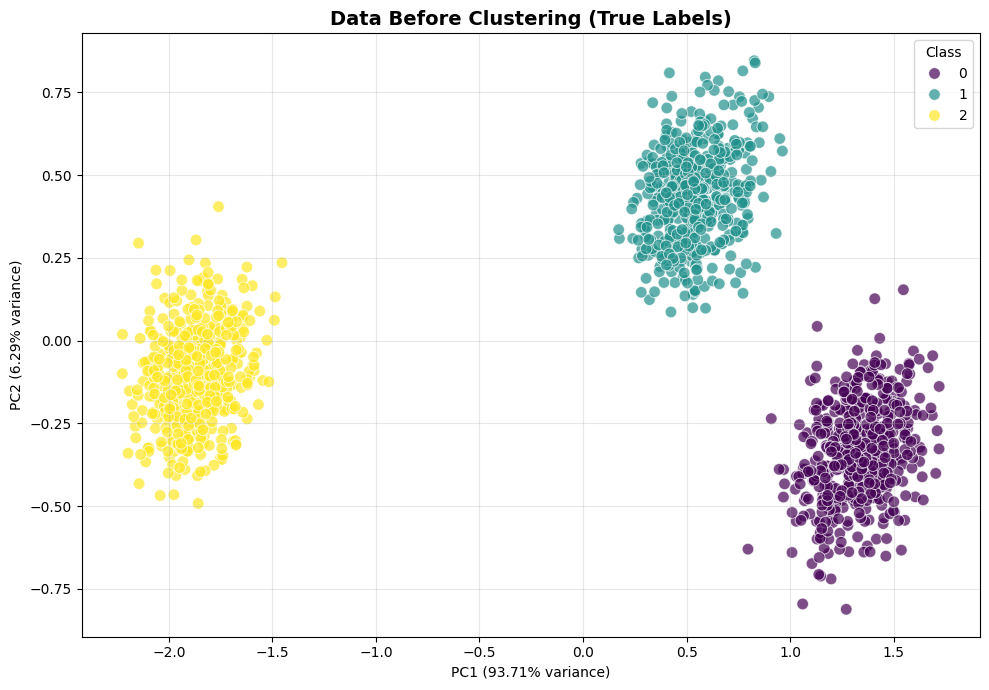

* Converged after 12 iterations
Cluster distribution: [ 234 1000  266]

Aligning clusters to true labels...
  Label mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
  Best alignment accuracy: 0.510667


Evaluation Metrics for K-Means:
      Metric     Value
0     Purity  0.666667
1   Accuracy  0.510667
2  Precision  0.500000
3     Recall  0.510667
4         F1  0.453728



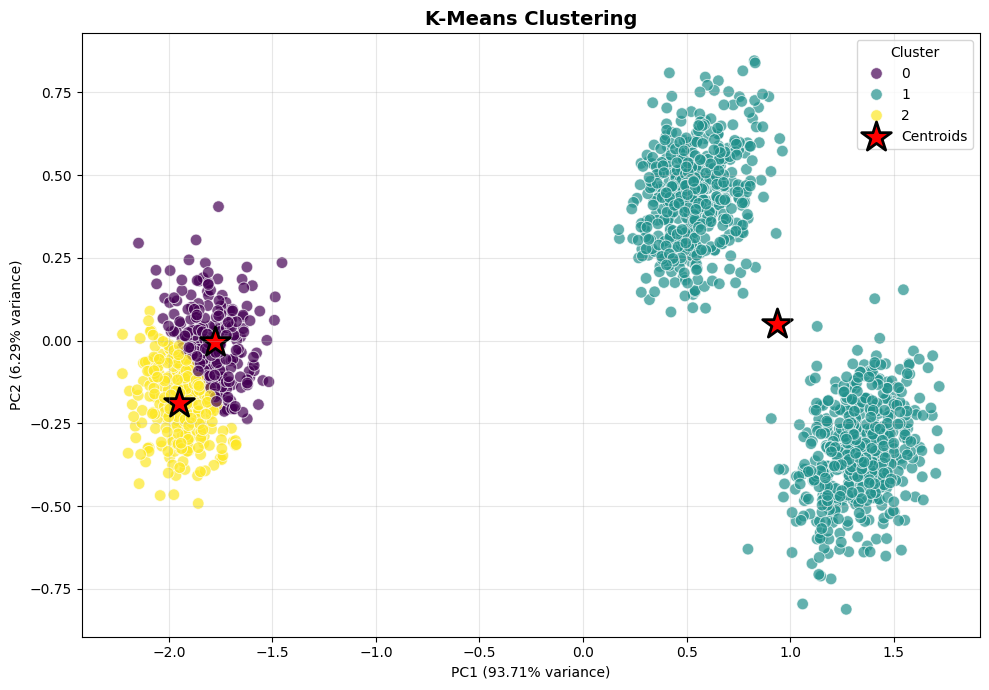

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================

filepath = "/content/blobs.csv"

def load_and_preprocess(filepath):
    """Load and preprocess data with standardization, duplicates, outliers."""
    try:
        df = pd.read_csv(filepath, header=None)
    except:
        print(f"Error loading file: {filepath}")
        return None

    print(f"Original shape: {df.shape}")

    # Remove duplicates
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - len(df)} duplicate rows")

    # Outlier removal using Z-score (only on feature columns)
    # Commented out as it was removing all data points for this dataset.
    # If outlier removal is desired, consider a less aggressive threshold or method.
    features = df.columns[:-1]
    # z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())
    # initial_rows = len(df)
    # df = df[(z_scores < 3).all(axis=1)]
    # print(f"Removed {initial_rows - len(df)} outliers using Z-score")

    if df.empty:
        print("Warning: DataFrame is empty after preprocessing. Cannot proceed.")
        return None

    # Standardization
    df[features] = (df[features] - df[features].mean()) / df[features].std()

    print(f"Shape after preprocessing: {df.shape}")
    print("Data standardized using Z-score normalization\n")
    return df


# ==========================================
# 2. K-Means from Scratch (Euclidean Distance)
# ==========================================

def k_means_clustering(data, k=3, max_iter=300, tol=1e-4, random_seed=42):
    """K-Means implementation using Euclidean distance."""
    np.random.seed(random_seed)
    N = data.shape[0]

    # Initialize centroids
    centroids_idx = np.random.choice(N, k, replace=False)
    centroids = data[centroids_idx]

    for it in range(max_iter):

        # Euclidean distances
        distances = np.zeros((N, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)

        # Assign clusters
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])

        # Check convergence
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"* Converged after {it+1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. Align Clusters to True Labels (FIXED)
# ==========================================

def align_labels(y_pred, y_true):
    """Align cluster labels to true labels by finding best matching."""
    from itertools import permutations

    best_accuracy = 0
    best_mapping = {}

    # Try all possible label permutations
    for perm in permutations(np.unique(y_pred)):
        mapping = {old: new for old, new in zip(np.unique(y_pred), perm)}
        y_aligned = np.array([mapping[label] for label in y_pred])
        acc = accuracy_score(y_true, y_aligned)

        if acc > best_accuracy:
            best_accuracy = acc
            best_mapping = mapping

    y_aligned = np.array([best_mapping[label] for label in y_pred])
    print(f"  Label mapping: {best_mapping}")
    print(f"  Best alignment accuracy: {best_accuracy:.6f}")

    return y_aligned


# ==========================================
# 4. Purity Score
# ==========================================

def purity_score(y_true, y_pred):
    """Purity calculation (cluster -> majority class)."""
    y_true = y_true.astype(int)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) > 0:
            total += np.bincount(true_labels).max()
    return total / len(y_true)


# ==========================================
# 5. Execution
# ==========================================

df = load_and_preprocess(filepath)

if df is not None:
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values.astype(int)

    # Class distribution
    print("Class counts:", np.bincount(y_true))
    print()

    # ==========================================
    # PCA Visualization BEFORE Clustering
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true,
                    palette='viridis', s=70, alpha=0.7)
    plt.title("Data Before Clustering (True Labels)", fontsize=14, fontweight='bold')
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(title="Class", loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run K-means
    # Set k to match the number of true classes for proper comparison
    # The dataset has 3 classes, so k should be 3
    labels_pred, centroids = k_means_clustering(X, k=3)

    # Check cluster distribution
    print("Cluster distribution:", np.bincount(labels_pred))
    print()

    # Align clusters for metrics
    print("Aligning clusters to true labels...")
    labels_aligned = align_labels(labels_pred, y_true)
    print()

    # ==========================================
    # Metrics (using aligned labels)
    # ==========================================

    purity = purity_score(y_true, labels_pred)
    accuracy = accuracy_score(y_true, labels_aligned)
    # Fix: Set average parameter for multiclass classification
    precision = precision_score(y_true, labels_aligned, average='weighted', zero_division=0)
    recall = recall_score(y_true, labels_aligned, average='weighted', zero_division=0)
    f1 = f1_score(y_true, labels_aligned, average='weighted', zero_division=0)

    results = pd.DataFrame({
        "Metric": ["Purity", "Accuracy", "Precision", "Recall", "F1"],
        "Value": [purity, accuracy, precision, recall, f1]
    })

    print("\nEvaluation Metrics for K-Means:")
    print(results)
    print()

    # ==========================================
    # PCA Visualization
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids)

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = labels_pred

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster',
                    palette='viridis', s=70, alpha=0.7)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        color='red', marker='*', s=500, edgecolors='black', linewidths=2,
        label='Centroids'
    )
    plt.title("K-Means Clustering", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster", loc='best')
    plt.grid(alpha=0.3)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.tight_layout()
    plt.show()

Original shape: (1500, 3)
Removed 0 duplicate rows
Shape after preprocessing: (1500, 3)
Data standardized using Z-score normalization

Class counts: [500 500 500]



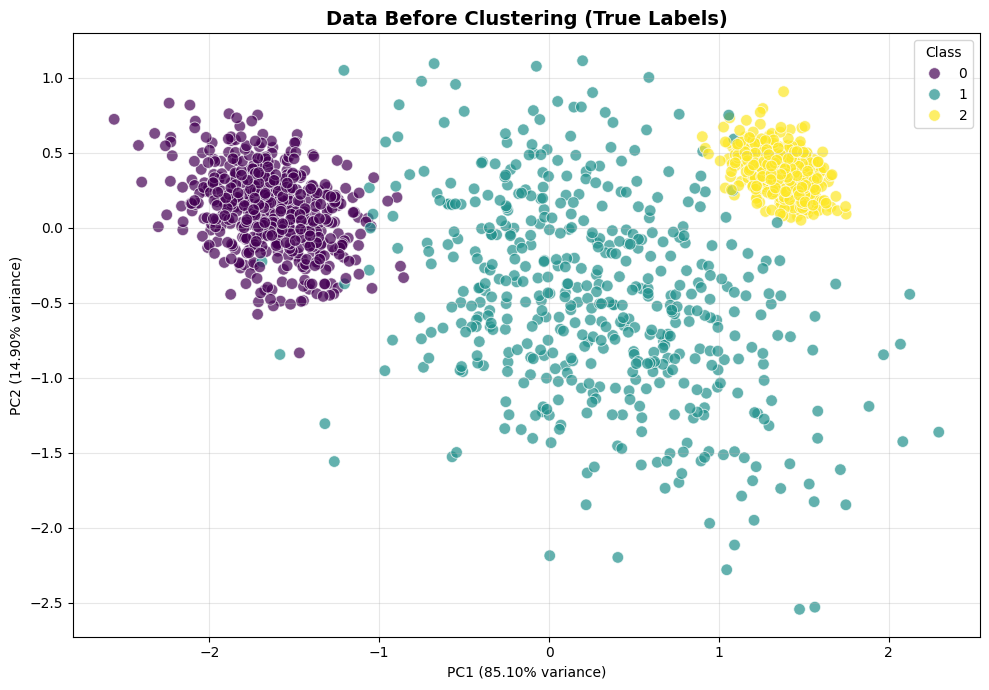

* Converged after 9 iterations
Cluster distribution: [538 565 397]

Aligning clusters to true labels...
  Label mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(2), np.int64(2): np.int64(1)}
  Best alignment accuracy: 0.931333


Evaluation Metrics for K-Means:
      Metric     Value
0     Purity  0.931333
1   Accuracy  0.931333
2  Precision  0.938108
3     Recall  0.931333
4         F1  0.929177



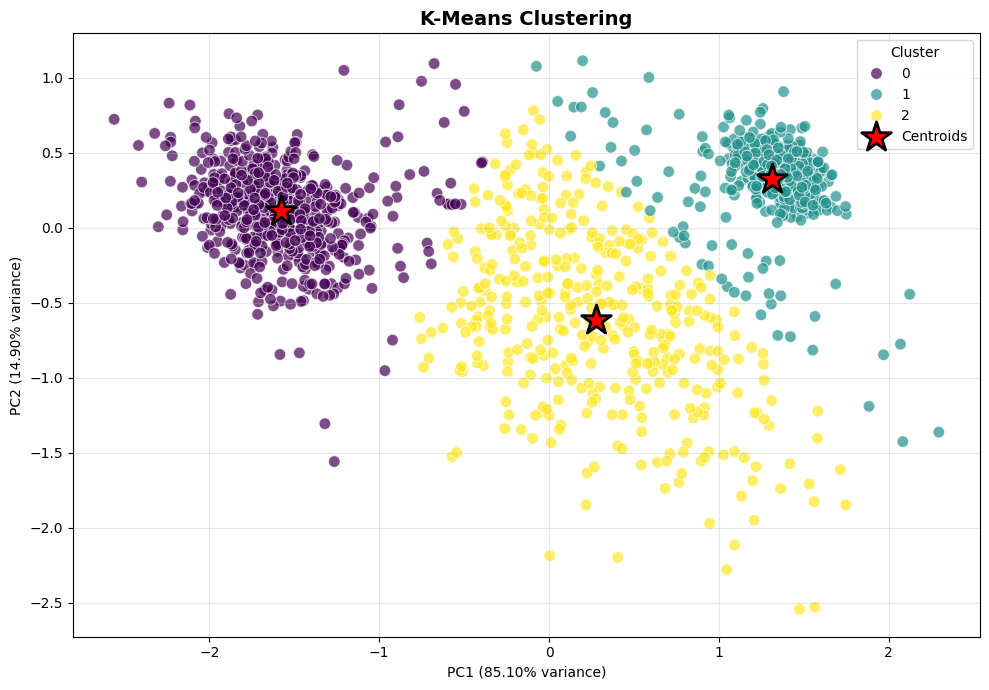

In [3]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================

filepath = "/content/varied.csv"

def load_and_preprocess(filepath):
    """Load and preprocess data with standardization, duplicates, outliers."""
    try:
        df = pd.read_csv(filepath, header=None)
    except:
        print(f"Error loading file: {filepath}")
        return None

    print(f"Original shape: {df.shape}")

    # Remove duplicates
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - len(df)} duplicate rows")

    # Outlier removal using Z-score (only on feature columns)
    # Commented out as it was removing all data points for this dataset.
    # If outlier removal is desired, consider a less aggressive threshold or method.
    features = df.columns[:-1]
    # z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())
    # initial_rows = len(df)
    # df = df[(z_scores < 3).all(axis=1)]
    # print(f"Removed {initial_rows - len(df)} outliers using Z-score")

    if df.empty:
        print("Warning: DataFrame is empty after preprocessing. Cannot proceed.")
        return None

    # Standardization
    df[features] = (df[features] - df[features].mean()) / df[features].std()

    print(f"Shape after preprocessing: {df.shape}")
    print("Data standardized using Z-score normalization\n")
    return df


# ==========================================
# 2. K-Means from Scratch (Euclidean Distance)
# ==========================================

def k_means_clustering(data, k=3, max_iter=300, tol=1e-4, random_seed=42):
    """K-Means implementation using Euclidean distance."""
    np.random.seed(random_seed)
    N = data.shape[0]

    # Initialize centroids
    centroids_idx = np.random.choice(N, k, replace=False)
    centroids = data[centroids_idx]

    for it in range(max_iter):

        # Euclidean distances
        distances = np.zeros((N, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)

        # Assign clusters
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])

        # Check convergence
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"* Converged after {it+1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. Align Clusters to True Labels (FIXED)
# ==========================================

def align_labels(y_pred, y_true):
    """Align cluster labels to true labels by finding best matching."""
    from itertools import permutations

    best_accuracy = 0
    best_mapping = {}

    # Try all possible label permutations
    for perm in permutations(np.unique(y_pred)):
        mapping = {old: new for old, new in zip(np.unique(y_pred), perm)}
        y_aligned = np.array([mapping[label] for label in y_pred])
        acc = accuracy_score(y_true, y_aligned)

        if acc > best_accuracy:
            best_accuracy = acc
            best_mapping = mapping

    y_aligned = np.array([best_mapping[label] for label in y_pred])
    print(f"  Label mapping: {best_mapping}")
    print(f"  Best alignment accuracy: {best_accuracy:.6f}")

    return y_aligned


# ==========================================
# 4. Purity Score
# ==========================================

def purity_score(y_true, y_pred):
    """Purity calculation (cluster -> majority class)."""
    y_true = y_true.astype(int)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) > 0:
            total += np.bincount(true_labels).max()
    return total / len(y_true)


# ==========================================
# 5. Execution
# ==========================================

df = load_and_preprocess(filepath)

if df is not None:
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values.astype(int)

    # Class distribution
    print("Class counts:", np.bincount(y_true))
    print()

    # ==========================================
    # PCA Visualization BEFORE Clustering
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true,
                    palette='viridis', s=70, alpha=0.7)
    plt.title("Data Before Clustering (True Labels)", fontsize=14, fontweight='bold')
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(title="Class", loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run K-means
    # Set k to match the number of true classes for proper comparison
    # The dataset has 3 classes, so k should be 3
    labels_pred, centroids = k_means_clustering(X, k=3)

    # Check cluster distribution
    print("Cluster distribution:", np.bincount(labels_pred))
    print()

    # Align clusters for metrics
    print("Aligning clusters to true labels...")
    labels_aligned = align_labels(labels_pred, y_true)
    print()

    # ==========================================
    # Metrics (using aligned labels)
    # ==========================================

    purity = purity_score(y_true, labels_pred)
    accuracy = accuracy_score(y_true, labels_aligned)
    # Fix: Set average parameter for multiclass classification
    precision = precision_score(y_true, labels_aligned, average='weighted', zero_division=0)
    recall = recall_score(y_true, labels_aligned, average='weighted', zero_division=0)
    f1 = f1_score(y_true, labels_aligned, average='weighted', zero_division=0)

    results = pd.DataFrame({
        "Metric": ["Purity", "Accuracy", "Precision", "Recall", "F1"],
        "Value": [purity, accuracy, precision, recall, f1]
    })

    print("\nEvaluation Metrics for K-Means:")
    print(results)
    print()

    # ==========================================
    # PCA Visualization
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids)

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = labels_pred

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster',
                    palette='viridis', s=70, alpha=0.7)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        color='red', marker='*', s=500, edgecolors='black', linewidths=2,
        label='Centroids'
    )
    plt.title("K-Means Clustering", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster", loc='best')
    plt.grid(alpha=0.3)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.tight_layout()
    plt.show()

Original shape: (178, 14)
Removed 0 duplicate rows
Shape after preprocessing: (178, 14)
Data standardized using Z-score normalization

Class counts: [48 59 71]



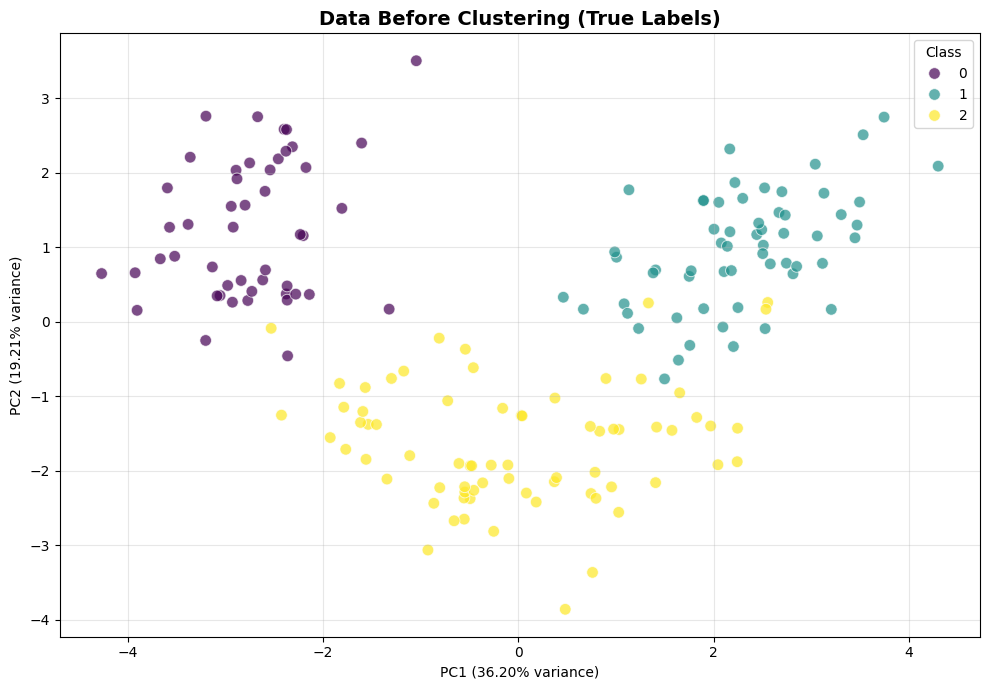

* Converged after 10 iterations
Cluster distribution: [65 62 51]

Aligning clusters to true labels...
  Label mapping: {np.int64(0): np.int64(2), np.int64(1): np.int64(1), np.int64(2): np.int64(0)}
  Best alignment accuracy: 0.966292


Evaluation Metrics for K-Means:
      Metric     Value
0     Purity  0.966292
1   Accuracy  0.966292
2  Precision  0.968099
3     Recall  0.966292
4         F1  0.966013



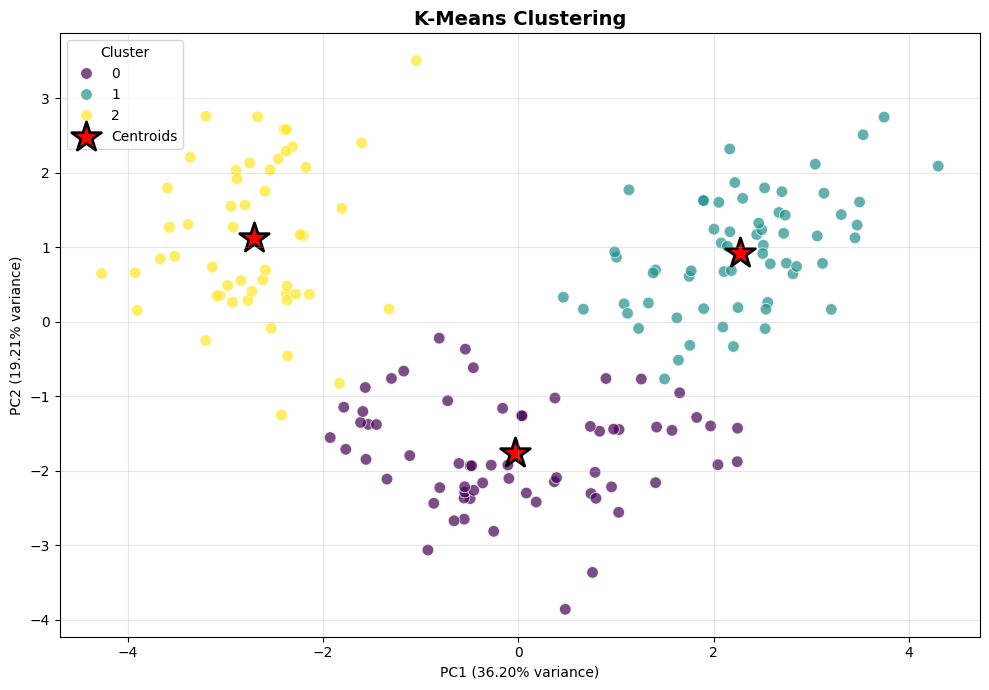

In [4]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================

filepath = "/content/wine.csv"

def load_and_preprocess(filepath):
    """Load and preprocess data with standardization, duplicates, outliers."""
    try:
        df = pd.read_csv(filepath, header=None)
    except:
        print(f"Error loading file: {filepath}")
        return None

    print(f"Original shape: {df.shape}")

    # Remove duplicates
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - len(df)} duplicate rows")

    # Outlier removal using Z-score (only on feature columns)
    # Commented out as it was removing all data points for this dataset.
    # If outlier removal is desired, consider a less aggressive threshold or method.
    features = df.columns[:-1]
    # z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())
    # initial_rows = len(df)
    # df = df[(z_scores < 3).all(axis=1)]
    # print(f"Removed {initial_rows - len(df)} outliers using Z-score")

    if df.empty:
        print("Warning: DataFrame is empty after preprocessing. Cannot proceed.")
        return None

    # Standardization
    df[features] = (df[features] - df[features].mean()) / df[features].std()

    print(f"Shape after preprocessing: {df.shape}")
    print("Data standardized using Z-score normalization\n")
    return df


# ==========================================
# 2. K-Means from Scratch (Euclidean Distance)
# ==========================================

def k_means_clustering(data, k=3, max_iter=300, tol=1e-4, random_seed=42):
    """K-Means implementation using Euclidean distance."""
    np.random.seed(random_seed)
    N = data.shape[0]

    # Initialize centroids
    centroids_idx = np.random.choice(N, k, replace=False)
    centroids = data[centroids_idx]

    for it in range(max_iter):

        # Euclidean distances
        distances = np.zeros((N, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)

        # Assign clusters
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])

        # Check convergence
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"* Converged after {it+1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. Align Clusters to True Labels (FIXED)
# ==========================================

def align_labels(y_pred, y_true):
    """Align cluster labels to true labels by finding best matching."""
    from itertools import permutations

    best_accuracy = 0
    best_mapping = {}

    # Try all possible label permutations
    for perm in permutations(np.unique(y_pred)):
        mapping = {old: new for old, new in zip(np.unique(y_pred), perm)}
        y_aligned = np.array([mapping[label] for label in y_pred])
        acc = accuracy_score(y_true, y_aligned)

        if acc > best_accuracy:
            best_accuracy = acc
            best_mapping = mapping

    y_aligned = np.array([best_mapping[label] for label in y_pred])
    print(f"  Label mapping: {best_mapping}")
    print(f"  Best alignment accuracy: {best_accuracy:.6f}")

    return y_aligned


# ==========================================
# 4. Purity Score
# ==========================================

def purity_score(y_true, y_pred):
    """Purity calculation (cluster -> majority class)."""
    y_true = y_true.astype(int)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) > 0:
            total += np.bincount(true_labels).max()
    return total / len(y_true)


# ==========================================
# 5. Execution
# ==========================================

df = load_and_preprocess(filepath)

if df is not None:
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values.astype(int)

    # Class distribution
    print("Class counts:", np.bincount(y_true))
    print()

    # ==========================================
    # PCA Visualization BEFORE Clustering
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true,
                    palette='viridis', s=70, alpha=0.7)
    plt.title("Data Before Clustering (True Labels)", fontsize=14, fontweight='bold')
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(title="Class", loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run K-means
    # Set k to match the number of true classes for proper comparison
    # The dataset has 3 classes, so k should be 3
    labels_pred, centroids = k_means_clustering(X, k=3)

    # Check cluster distribution
    print("Cluster distribution:", np.bincount(labels_pred))
    print()

    # Align clusters for metrics
    print("Aligning clusters to true labels...")
    labels_aligned = align_labels(labels_pred, y_true)
    print()

    # ==========================================
    # Metrics (using aligned labels)
    # ==========================================

    purity = purity_score(y_true, labels_pred)
    accuracy = accuracy_score(y_true, labels_aligned)
    # Fix: Set average parameter for multiclass classification
    precision = precision_score(y_true, labels_aligned, average='weighted', zero_division=0)
    recall = recall_score(y_true, labels_aligned, average='weighted', zero_division=0)
    f1 = f1_score(y_true, labels_aligned, average='weighted', zero_division=0)

    results = pd.DataFrame({
        "Metric": ["Purity", "Accuracy", "Precision", "Recall", "F1"],
        "Value": [purity, accuracy, precision, recall, f1]
    })

    print("\nEvaluation Metrics for K-Means:")
    print(results)
    print()

    # ==========================================
    # PCA Visualization
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids)

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = labels_pred

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster',
                    palette='viridis', s=70, alpha=0.7)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        color='red', marker='*', s=500, edgecolors='black', linewidths=2,
        label='Centroids'
    )
    plt.title("K-Means Clustering", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster", loc='best')
    plt.grid(alpha=0.3)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.tight_layout()
    plt.show()

Original shape: (240, 3)
Removed 0 duplicate rows
Removed 0 outliers using Z-score
Shape after preprocessing: (240, 3)
Data standardized using Z-score normalization

Class counts: [153  87]



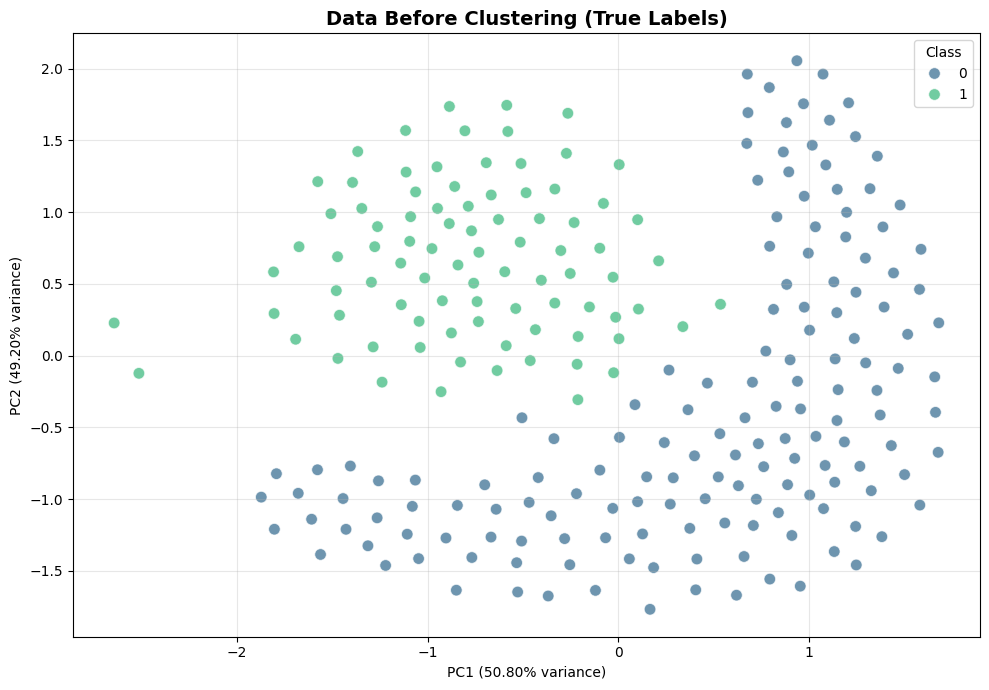

* Converged after 7 iterations
Cluster distribution: [123 117]

Aligning clusters to true labels...
  Label mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
  Best alignment accuracy: 0.816667


Evaluation Metrics for K-Means:
      Metric     Value
0     Purity  0.816667
1   Accuracy  0.816667
2  Precision  0.683761
3     Recall  0.919540
4         F1  0.784314



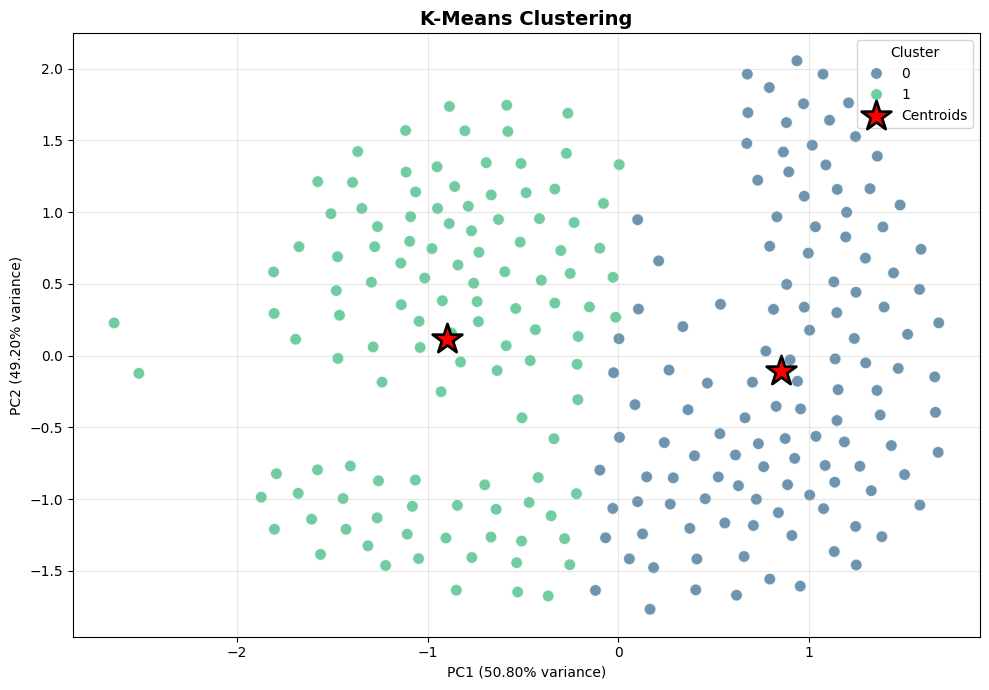

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Loading and Preprocessing
# ==========================================

filepath = "/content/flame.csv"

def load_and_preprocess(filepath):
    """Load and preprocess data with standardization, duplicates, outliers."""
    try:
        df = pd.read_csv(filepath, header=None)
    except:
        print(f"Error loading file: {filepath}")
        return None

    print(f"Original shape: {df.shape}")

    # Remove duplicates
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    print(f"Removed {initial_rows - len(df)} duplicate rows")

    # Outlier removal using Z-score (only on feature columns)
    features = df.columns[:-1]
    z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())
    initial_rows = len(df)
    df = df[(z_scores < 3).all(axis=1)]
    print(f"Removed {initial_rows - len(df)} outliers using Z-score")

    # Standardization
    df[features] = (df[features] - df[features].mean()) / df[features].std()

    print(f"Shape after preprocessing: {df.shape}")
    print("Data standardized using Z-score normalization\n")
    return df


# ==========================================
# 2. K-Means from Scratch (Euclidean Distance)
# ==========================================

def k_means_clustering(data, k=2, max_iter=300, tol=1e-4, random_seed=42):
    """K-Means implementation using Euclidean distance."""
    np.random.seed(random_seed)
    N = data.shape[0]

    # Initialize centroids
    centroids_idx = np.random.choice(N, k, replace=False)
    centroids = data[centroids_idx]

    for it in range(max_iter):

        # Euclidean distances
        distances = np.zeros((N, k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centroids[i], axis=1)

        # Assign clusters
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            data[labels == c].mean(axis=0) if np.any(labels == c) else centroids[c]
            for c in range(k)
        ])

        # Check convergence
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"* Converged after {it+1} iterations")
            break

        centroids = new_centroids

    return labels, centroids


# ==========================================
# 3. Align Clusters to True Labels (FIXED)
# ==========================================

def align_labels(y_pred, y_true):
    """Align cluster labels to true labels by finding best matching."""
    from itertools import permutations

    best_accuracy = 0
    best_mapping = {}

    # Try all possible label permutations
    for perm in permutations(np.unique(y_pred)):
        mapping = {old: new for old, new in zip(np.unique(y_pred), perm)}
        y_aligned = np.array([mapping[label] for label in y_pred])
        acc = accuracy_score(y_true, y_aligned)

        if acc > best_accuracy:
            best_accuracy = acc
            best_mapping = mapping

    y_aligned = np.array([best_mapping[label] for label in y_pred])
    print(f"  Label mapping: {best_mapping}")
    print(f"  Best alignment accuracy: {best_accuracy:.6f}")

    return y_aligned


# ==========================================
# 4. Purity Score
# ==========================================

def purity_score(y_true, y_pred):
    """Purity calculation (cluster -> majority class)."""
    y_true = y_true.astype(int)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        true_labels = y_true[idx]
        if len(true_labels) > 0:
            total += np.bincount(true_labels).max()
    return total / len(y_true)


# ==========================================
# 5. Execution
# ==========================================

df = load_and_preprocess(filepath)

if df is not None:
    X = df.iloc[:, :-1].values
    y_true = df.iloc[:, -1].values.astype(int)

    # Class distribution
    print("Class counts:", np.bincount(y_true))
    print()

    # ==========================================
    # PCA Visualization BEFORE Clustering
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true,
                    palette='viridis', s=70, alpha=0.7)
    plt.title("Data Before Clustering (True Labels)", fontsize=14, fontweight='bold')
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(title="Class", loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Run K-means
    labels_pred, centroids = k_means_clustering(X, k=2)

    # Check cluster distribution
    print("Cluster distribution:", np.bincount(labels_pred))
    print()

    # Align clusters for metrics
    print("Aligning clusters to true labels...")
    labels_aligned = align_labels(labels_pred, y_true)
    print()

    # ==========================================
    # Metrics (using aligned labels)
    # ==========================================

    purity = purity_score(y_true, labels_pred)
    accuracy = accuracy_score(y_true, labels_aligned)
    precision = precision_score(y_true, labels_aligned, zero_division=0)
    recall = recall_score(y_true, labels_aligned, zero_division=0)
    f1 = f1_score(y_true, labels_aligned, zero_division=0)

    results = pd.DataFrame({
        "Metric": ["Purity", "Accuracy", "Precision", "Recall", "F1"],
        "Value": [purity, accuracy, precision, recall, f1]
    })

    print("\nEvaluation Metrics for K-Means:")
    print(results)
    print()

    # ==========================================
    # PCA Visualization
    # ==========================================

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    centroids_pca = pca.transform(centroids)

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = labels_pred

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster',
                    palette='viridis', s=70, alpha=0.7)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        color='red', marker='*', s=500, edgecolors='black', linewidths=2,
        label='Centroids'
    )
    plt.title("K-Means Clustering", fontsize=14, fontweight='bold')
    plt.legend(title="Cluster", loc='best')
    plt.grid(alpha=0.3)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.tight_layout()
    plt.show()